In [84]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [85]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [86]:
print("X_tarin shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_tarin shape:  (60000, 28, 28)
y_train shape:  (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


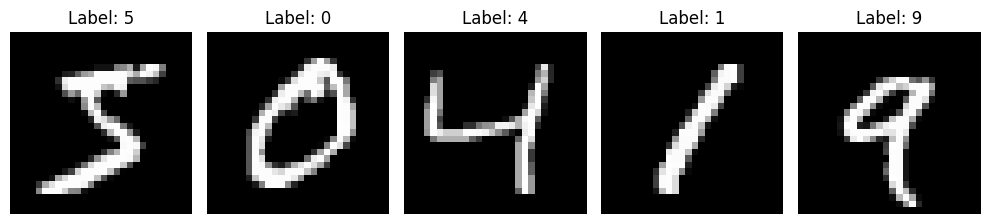

In [87]:
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [88]:
X_train = X_train.reshape(X_train.shape[0], -1).T
X_test = X_test.reshape(X_test.shape[0], -1).T

In [89]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (784, 60000)
X_test shape: (784, 10000)


In [90]:
def initialisation(dimensions: list[int]) -> dict:
    parameters = {}
    nbr_layers = len(dimensions)

    for i in range(1, nbr_layers):
        parameters["W" + str(i)] = np.random.randn(dimensions[i], dimensions[i - 1]) * np.sqrt(2 / dimensions[i - 1]) # more study
        parameters["b" + str(i)] = np.zeros((dimensions[i], 1)) 

    return parameters

In [91]:
parameters = initialisation([X_train.shape[0], 64, 32, 10])

for key, val in parameters.items():
    print(f"{key} : {val.shape}")

W1 : (64, 784)
b1 : (64, 1)
W2 : (32, 64)
b2 : (32, 1)
W3 : (10, 32)
b3 : (10, 1)


In [92]:
def ReLU(Z: np.ndarray) -> np.ndarray:
    return np.maximum(Z, 0)

def ReLU_derivative(Z: np.ndarray) -> np.ndarray:
    return Z > 0

def softmax(Z: np.ndarray):
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_propagation(X: np.ndarray, parameters: dict) -> dict:
    layer_values = {"A0": X}
    nbr_layers = len(parameters) // 2

    for i in range(1, nbr_layers):
        layer_values["Z" + str(i)] = parameters["W" + str(i)].dot(layer_values["A" + str(i - 1)]) + parameters["b" + str(i)]
        layer_values["A" + str(i)] = ReLU(layer_values["Z" + str(i)])
    
    layer_values["Z" + str(nbr_layers)] = parameters["W" + str(nbr_layers)].dot(layer_values["A" + str(nbr_layers - 1)]) + parameters["b" + str(nbr_layers)]
    layer_values["A" + str(nbr_layers)] = softmax(layer_values["Z" + str(nbr_layers)])

    return layer_values

In [93]:
layer_values = forward_propagation(X_train, parameters)

for key, val in layer_values.items():
    print(f"{key} : {val.shape}")

A0 : (784, 60000)
Z1 : (64, 60000)
A1 : (64, 60000)
Z2 : (32, 60000)
A2 : (32, 60000)
Z3 : (10, 60000)
A3 : (10, 60000)


In [94]:
def one_hot_encoding(y: np.ndarray) -> np.ndarray:
    res = np.zeros((y.shape[0], y.max() + 1))

    for i in range(res.shape[0]):
        res[i, y[i]] = 1
    return res.T

Y_train = one_hot_encoding(y_train)

In [95]:
for i in range(3):
    print(f"Label : {y_train[i]}  One-hot : ", Y_train[:, i])

Label : 5  One-hot :  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Label : 0  One-hot :  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Label : 4  One-hot :  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [96]:
def back_propagation(Y: np.ndarray, parameters: dict[str, np.ndarray], layer_values: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    m = Y.shape[1]
    nbr_layers = len(parameters) // 2
    dZ = layer_values["A" + str(nbr_layers)] - Y
    gradients = {}

    for i in reversed(range(1, nbr_layers + 1)):
        gradients["dW" + str(i)] = np.matmul(dZ, layer_values["A" + str(i - 1)].T) / m
        gradients["db" + str(i)] = np.sum(dZ, axis=1, keepdims=True) / m

        if i > 1:
            dZ = np.matmul(parameters["W" + str(i)].T, dZ) * ReLU_derivative(layer_values["Z" + str(i - 1)])
    return gradients


In [97]:
def update(parameters: np.ndarray, gradients: np.ndarray, learning_rate):
    nbr_layers = len(parameters) // 2

    for i in range(1, nbr_layers + 1):
        parameters["W" + str(i)] = parameters["W" + str(i)] - learning_rate * gradients["dW" + str(i)]
        parameters["b" + str(i)] = parameters["b" + str(i)] - learning_rate * gradients["db" + str(i)]
    
    return parameters

In [ ]:
def cross_entropy_loss(Y: np.ndarray, Y_hat: np.ndarray) -> float:
    m = Y.shape[1]
    epsilon = 1e-15
    Y_hat = np.clip(Y_hat, epsilon, 1 - epsilon)
    return -np.sum(Y * np.log(Y_hat)) / m

def accuracy(y: np.ndarray, predictions: np.ndarray) -> float:
    return np.sum(y == predictions) / y.shape[0]

def predict(Y_hat: np.ndarray) -> np.ndarray:
    return np.argmax(Y_hat, axis=0)

def visualisation(loss: list[float], acc: list[float], iterations: list[int]):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(iterations, loss, label="Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(iterations, acc, label="Accuracy")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.grid()

    plt.tight_layout()
    plt.show()

def neural_network(X: np.ndarray, y: np.ndarray, hidden_layers:tuple[int] = (128, 64, 32), learning_rate: float = 0.001, n_iter: int = 5000):
    np.random.seed(0)

    dimensions = [X.shape[0]] + list(hidden_layers) + [int(y.max() + 1)]
    parameters = initialisation(dimensions)
    nbr_layers = len(parameters) // 2
    Y = one_hot_encoding(y)

    train_loss = []
    train_acc = []
    for i in tqdm(range(n_iter)):
        layer_values = forward_propagation(X, parameters)
        gradients = back_propagation(Y, parameters, layer_values)
        parameters = update(parameters, gradients, learning_rate)

        if i % 10 == 0:
            train_loss.append(cross_entropy_loss(Y, layer_values["A" + str(nbr_layers)]))
            predictions = predict(layer_values["A" + str(nbr_layers)])
            train_acc.append(accuracy(y, predictions))
    
    iterations = range(0, n_iter, 10)
    visualisation(train_loss, train_acc, iterations)


    return parameters

100%|██████████| 5000/5000 [1:29:36<00:00,  1.08s/it]     


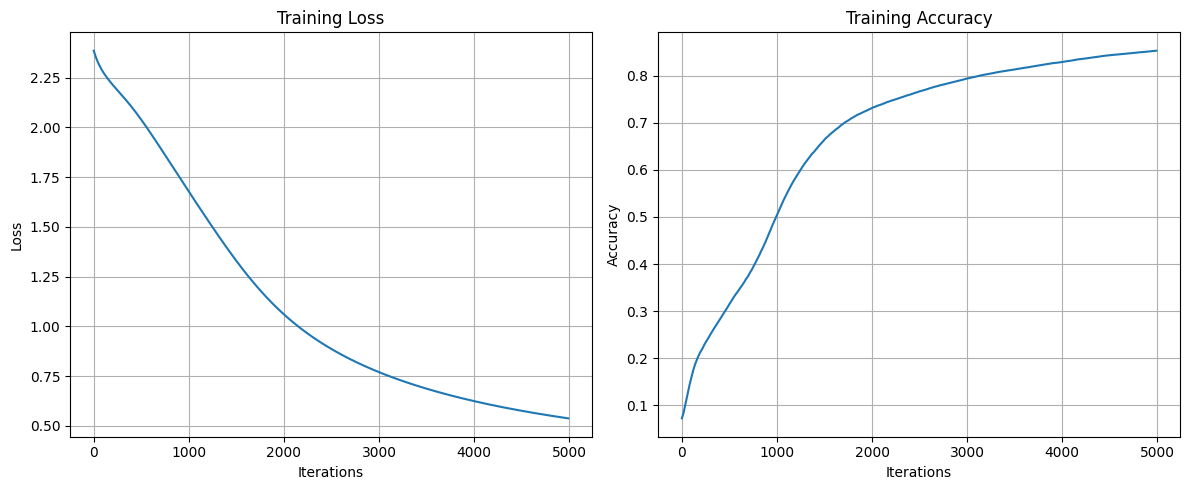

In [99]:
parameters = neural_network(X_train, y_train)

In [101]:
print(accuracy(y_test, predict(forward_propagation(X_test, parameters)["A" + str(len(parameters) // 2)])))

0.8589
